# Assignment 1 - Outlier Detection

*Due: Friday, 28 November, 2025 at 17:00 CET*

For the first assignment of the course Applications of Machine Learning (INFOB3APML), you will learn to use decision tree, random forest, and isolation forest to detect an outlier class. The objectives of this assignment are:
- use the supervised classification algorithms to classify outliers in real-life data sets
- perform cross validation and fine-tune the model parameters of each algorithm
- use the unsupervised outlier detection algorithms to detect outliers in real-life data sets
- calculate model performance (e.g., accuracy, recall, precision, f1)
- design experiments to compare performance of algorithms
- reflect on the difference between different models


This assignment includes three algorithms: DT, RF, and IF. The first task is to perform data exploration. In Task 2-4, you will use the three algorithms to classify outliers, respectively. In Task 5, you will compare the algorithms and evaluate their results. Please note that Task 2-4 have the following structure:
1. First, find the library (e.g., sklearn examples) and try out the algorithm by simply training the model on the training data (do not consider any parameters or cross validation just yet); 
2. Train the model with the training data by using cross validation and find the best parameter setting for the parameters of interest;
3. Report the average validation accuracy, recall, precision, and F1 scores of all validation sets;
4. Finally, test the optimal model that has the best fitting parameters on your (held-out) test data, and report the test accuracy, precision, recall, and F1. 

Note that, in Task 5, you will need all the calculated accuracy, precision, recall and F1 measures from previous tasks. Make sure you save these to a list or dictionary so you can easily evaluate and compare the results. 




## Task 1: Exploring the data set
 
 

### Data set: Bank Marketing


Import the file *dataBank-additional-full_normalised.csv* to load the preprocessed data set. "*The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.*"


Use the column "label" as the response variable:
- The instances labeled with 1 are the "outliers", in this case the class we would like to detect accurately; 
- The instance labeled with 0 are the "inliers".


The original data description can be found via the link here below. You will also find some explanations regarding the features under the section "Attribute Information".  
https://archive.ics.uci.edu/ml/datasets/bank+marketing





In [2]:
# Import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import data
data = pd.read_csv('./dataBank-additional-full_normalised_sampled.csv', sep=',')
print(data.columns)

Index(['age', 'job=housemaid', 'job=services', 'job=admin.', 'job=blue-collar',
       'job=technician', 'job=retired', 'job=management', 'job=unemployed',
       'job=self-employed', 'job=unknown', 'job=entrepreneur', 'job=student',
       'marital=married', 'marital=single', 'marital=divorced',
       'marital=unknown', 'education=basic.4y', 'education=high.school',
       'education=basic.6y', 'education=basic.9y',
       'education=professional.course', 'education=unknown',
       'education=university.degree', 'education=illiterate', 'default=0',
       'default=unknown', 'default=1', 'housing=0', 'housing=1',
       'housing=unknown', 'loan=0', 'loan=1', 'loan=unknown',
       'contact=cellular', 'month=may', 'month=jun', 'month=jul', 'month=aug',
       'month=oct', 'month=nov', 'month=dec', 'month=mar', 'month=apr',
       'month=sep', 'day_of_week=mon', 'day_of_week=tue', 'day_of_week=wed',
       'day_of_week=thu', 'day_of_week=fri', 'duration', 'campaign', 'pdays',
       'p


### 1.1. Exploratory data analysis

For the data set, create 2-3 figures and tables that will help you understand the data. 


During the data exploration, you, as a team, are trying to get an impression about the data. You will create figures and/or tables that help you to get to know the data. While exploring the data, you may also consider answering the following questions, which may help you understand the data better. For example, 

- How many instances are there in each class? Are the classes imbalanced?
- How many variables are in the data? What is the data type and the distribution of each variable? 
- Are the variables informative?
- Are any pair of the potential predictor variables highly correlated?
- (Should the variables be normalized or not?)
- (Any relevant, useful preprocessing steps that may be taken?)

#### Tips: 

Make sure to at least check the data type of each variable and to understand the distribution of each variable, especially the response variable. 

Try to find out what factors seem to determine whether an instance is an outlier or not. What do you conclude?

*For creating data visualizations, you may consider using the matplot library and visit the [matplot gallery](https://matplotlib.org/stable/gallery/index.html) for inspiration (e.g., histograms for distribution, or heatmaps for feature correlation).*



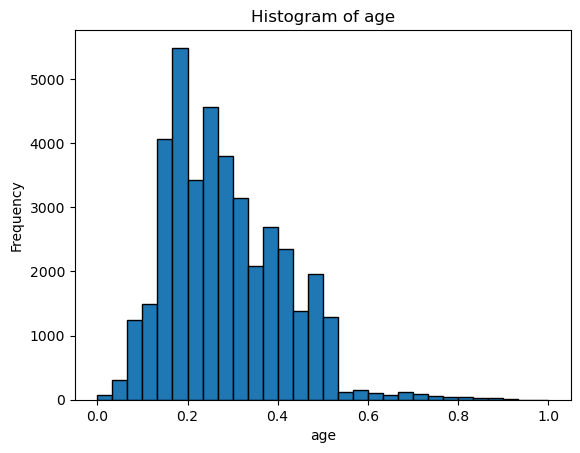

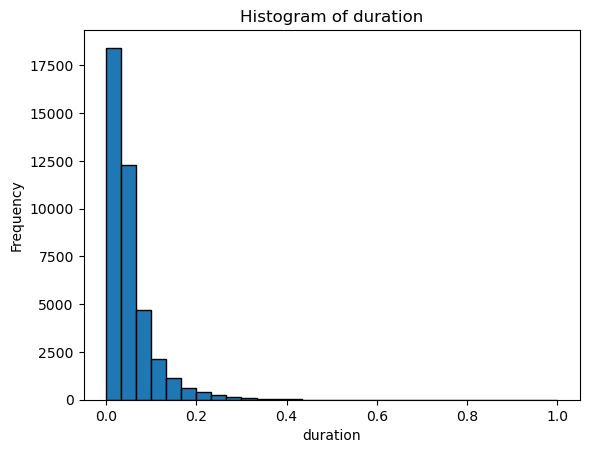

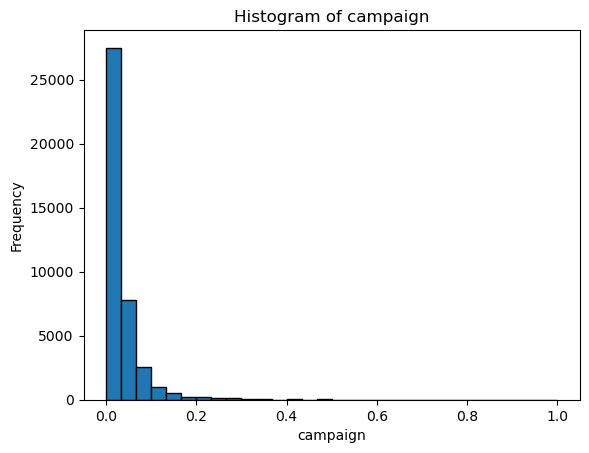

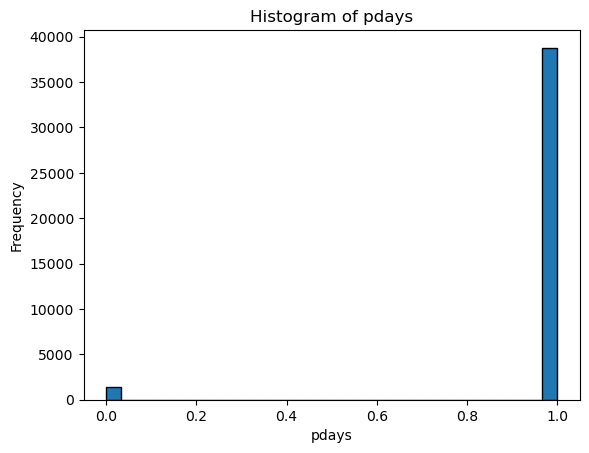

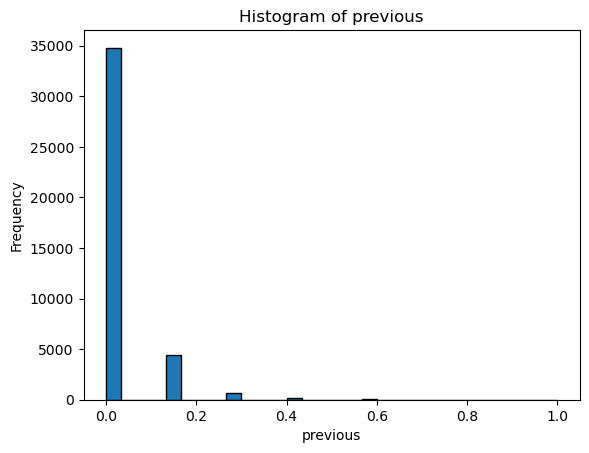

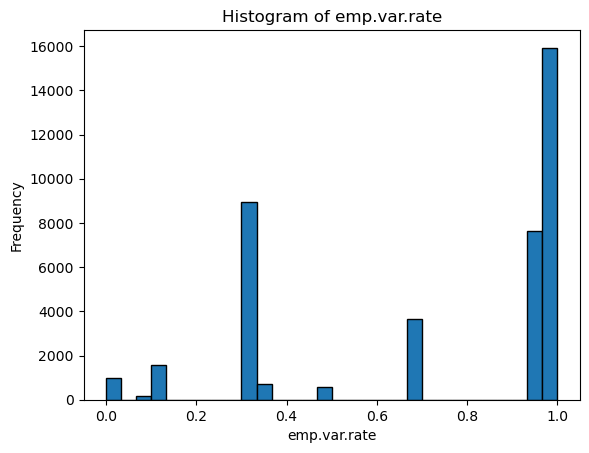

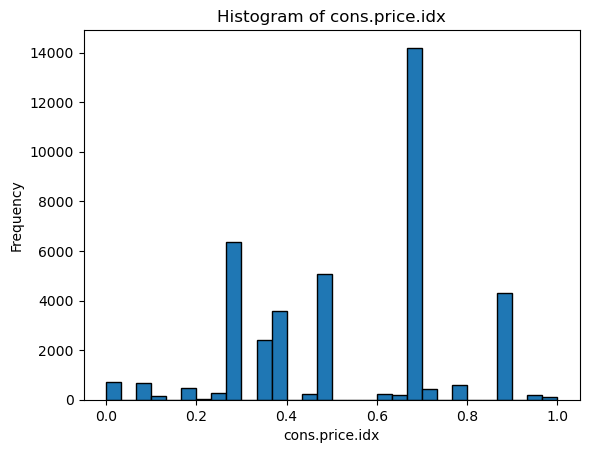

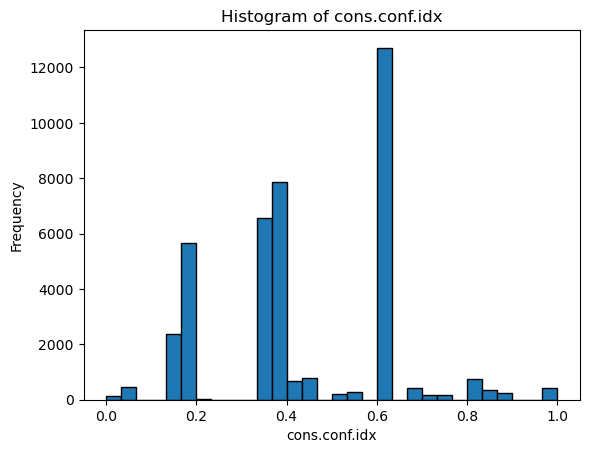

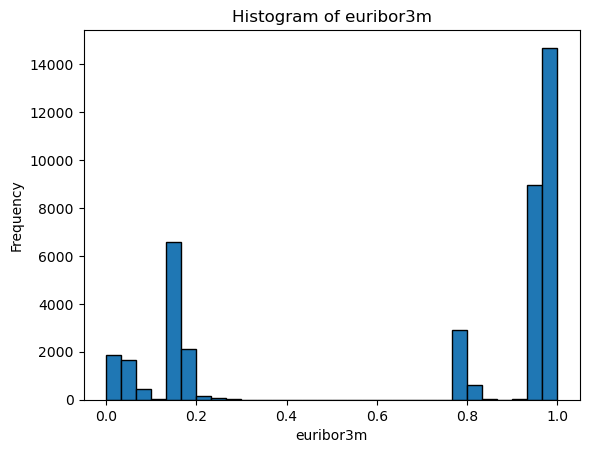

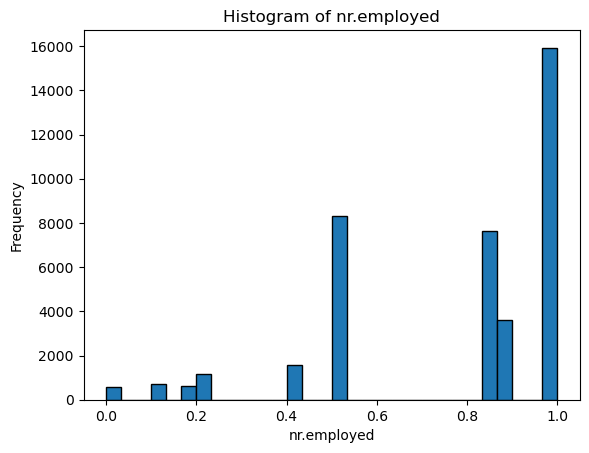

<Axes: >

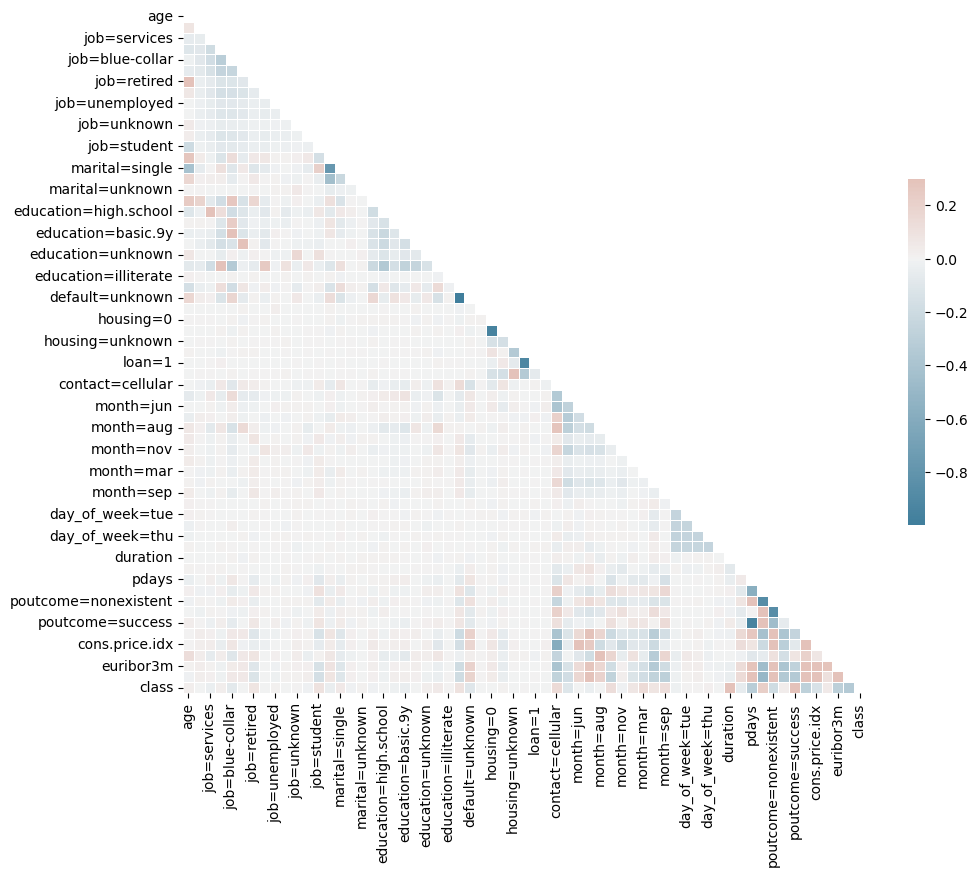

In [3]:
# import packages
import matplotlib.pyplot as plt

# # create a histogram of all variables that contain float64 data
data.describe()
for col_name, dtype in data.dtypes.items(): 
    if dtype == 'float64':
        plt.figure()
        plt.hist(data[col_name], bins=30, edgecolor='black')
        plt.title(f'Histogram of {col_name}')
        plt.xlabel(col_name)
        plt.ylabel('Frequency')
        plt.show()

# print the amount of instances per column
# for col_name in data.columns: 
#     print(f'Column:{col_name}, Amount of instances: {data[col_name].count()}')     

# find correlation between certain predictor variables
# target variable is: "label"
correlation = data.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

# # TODO: plot figure(s)




### 1.2. Creating Train and Test data sets

Create a training and a held-out test data set. *Later in Task 2-4, the training data will be used to perform cross-validation. The held-out test data will be used to evaluate the performance of the selected models.*

Choose the size of your test data and motivate your choice when you discuss the experiment setup in your report. 

Tips: 

*You may use the [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) class provided by sklearn*

In [4]:
# import method to make a train/test split
from sklearn.model_selection import train_test_split

# copy data
df = data.copy()

# create X and y
features = ['age', 'job=housemaid', 'job=services', 'job=admin.', 'job=blue-collar',
       'job=technician', 'job=retired', 'job=management', 'job=unemployed',
       'job=self-employed', 'job=unknown', 'job=entrepreneur', 'job=student',
       'marital=married', 'marital=single', 'marital=divorced',
       'marital=unknown', 'education=basic.4y', 'education=high.school',
       'education=basic.6y', 'education=basic.9y',
       'education=professional.course', 'education=unknown',
       'education=university.degree', 'education=illiterate', 'default=0',
       'default=unknown', 'default=1', 'housing=0', 'housing=1',
       'housing=unknown', 'loan=0', 'loan=1', 'loan=unknown',
       'contact=cellular', 'month=may', 'month=jun', 'month=jul', 'month=aug',
       'month=oct', 'month=nov', 'month=dec', 'month=mar', 'month=apr',
       'month=sep', 'day_of_week=mon', 'day_of_week=tue', 'day_of_week=wed',
       'day_of_week=thu', 'day_of_week=fri', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome=nonexistent', 'poutcome=failure',
       'poutcome=success', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed']

X = df[features]
y = df[['class']]

X = X[0:14000]
y = y[0:14000]

# # TODO: create training data and held-out test data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y,test_size=0.2)

## Task 2: Decision Trees 
### - Outlier Detection as a Supervised Classification

### 2.1 Training a Decision Tree

Use the basic [Decision Tree](http://scikit-learn.org/stable/modules/tree.html#tree) library in sklearn to learn a decision tree model by fitting the full training data.

Show/plot the tree diagram and also plot the feature importances. 
What do you observe?


#### Tips:

To show the tree diagram, you may use the graphviz library or use the plot_tree function, see https://scikit-learn.org/stable/modules/tree.html




Feature: age, Score: 0.07403483375651104
Feature: duration, Score: 0.33868467487465603
Feature: euribor3m, Score: 0.06396713434483085
Feature: nr.employed, Score: 0.15273447442433627


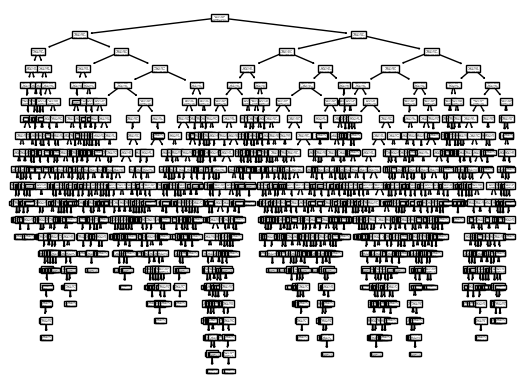

In [5]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# TODO: learn a decision tree using default parameters
cl = tree.DecisionTreeClassifier()
cl.fit(X_train, y_train)

# TODO: plot the tree
tree.plot_tree(cl)

# TODO: plot the feature importances
importance = cl.feature_importances_

# find corresponding feature names for accuracy > 0.05
for i, v in enumerate(importance):  
    if v > 0.05:
        print(f'Feature: {features[i]}, Score: {v}')


### 2.2 Confusion Matrix and Accuracy

Compute the *confusion matrix* and *accuracy* of the tree using the held-out data set. Moreover, also compute the *recall*, *precision*, and *F1-score* of the tree. 


For this part, you can either implement your own functions or use the following scikit-learn libraries.  
- [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
- [accuracy score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)
- [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)
- [f1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)
- [classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report)


Reflect on the performance of the model and be aware of the difference between *accuracy* and *F1-score*. How good is this decision tree model for outlier detection?

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score


# use the model to make predictions for the test data set
y_pred = cl.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n=== Confusion Matrix ===")
print(conf_matrix)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Evaluation Metrics ===
Accuracy : 0.8921
Precision: 0.4880
Recall   : 0.4814
F1-score : 0.4846

=== Confusion Matrix ===
[[2356  149]
 [ 153  142]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2505
           1       0.49      0.48      0.48       295

    accuracy                           0.89      2800
   macro avg       0.71      0.71      0.71      2800
weighted avg       0.89      0.89      0.89      2800



### 2.3 Features to Tree  (optional)

Use the training data to re-fit a new decision tree with the parameter max_depth set to 4. Show the tree diagram and also plot the feature importances. 

Recalculate the performance of this simpler model. 

What do you observe?


=== Evaluation Metrics ===
Accuracy : 0.9125
Precision: 0.6359
Recall   : 0.3966
F1-score : 0.4885

=== Confusion Matrix ===
[[2438   67]
 [ 178  117]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2505
           1       0.64      0.40      0.49       295

    accuracy                           0.91      2800
   macro avg       0.78      0.68      0.72      2800
weighted avg       0.90      0.91      0.90      2800



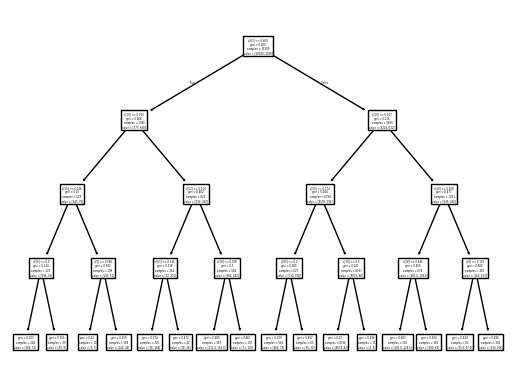

In [7]:
# TODO: learn a decision tree with maximal depth 4
cl = tree.DecisionTreeClassifier(max_depth=4)
cl.fit(X_train, y_train)

# TODO: plot the tree
tree.plot_tree(cl)

# use the model to make predictions for the test data set
y_pred = cl.predict(X_test)

# TODO: compute accuracy, recall, precision, and f1 score
conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n=== Confusion Matrix ===")
print(conf_matrix)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


### 2.4 Cross validation (optional)

The code example shown here below uses the [kfold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold) method to implement 5-fold cross-validation. Moreover, it uses the cross validation to explore how the max_depth influences the model performance. It keeps track of the validation accuracy scores and F1-scores across the 5 folds. 


Now, change the code to also compute the recall and precision. 


In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# create 5-fold cross-validation
nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

# Search the parameter among the following
C = np.arange(2, 10)

# init metrics: rows = folds, cols = different max_depths
acc = np.zeros((nk, len(C)))
f1  = np.zeros((nk, len(C)))
prec = np.zeros((nk, len(C)))
rec = np.zeros((nk, len(C)))

i = 0
for train_index, val_index in kf.split(X_train):
    X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    j = 0
    for c in C:
        dt = tree.DecisionTreeClassifier(min_samples_leaf=1, max_depth=c)
        dt.fit(X_t, y_t)
        yhat = dt.predict(X_val)

        acc[i][j]  = accuracy_score(y_val, yhat)
        f1[i][j]   = f1_score(y_val, yhat)
        prec[i][j] = precision_score(y_val, yhat)
        rec[i][j]  = recall_score(y_val, yhat)

        j += 1
    i += 1

# Print the results
print("=== Mean Accuracy per max_depth ===")
print(np.mean(acc, axis=0))
print("Selected model index:", np.argmax(np.mean(acc, axis=0)))

print("\n=== Mean F1 per max_depth ===")
print(np.mean(f1, axis=0))
print("Selected model index:", np.argmax(np.mean(f1, axis=0)))

print("\n=== Mean Precision per max_depth ===")
print(np.mean(prec, axis=0))
print("Selected model index:", np.argmax(np.mean(prec, axis=0)))

print("\n=== Mean Recall per max_depth ===")
print(np.mean(rec, axis=0))
print("Selected model index:", np.argmax(np.mean(rec, axis=0)))


=== Mean Accuracy per max_depth ===
[0.90723214 0.9125     0.91508929 0.91125    0.91321429 0.91178571
 0.91053571 0.90589286]
Selected model index: 2

=== Mean F1 per max_depth ===
[0.47713606 0.53307336 0.55272732 0.51916873 0.56162565 0.55007648
 0.55162913 0.52629926]
Selected model index: 4

=== Mean Precision per max_depth ===
[0.58897563 0.62168677 0.62084108 0.61401731 0.60554302 0.59449321
 0.58177812 0.56180457]
Selected model index: 1

=== Mean Recall per max_depth ===
[0.40257972 0.48975773 0.50419549 0.46109768 0.52620475 0.51600426
 0.52596651 0.50166173]
Selected model index: 4


### 2.5 Tree Tuning



The built-in decision tree algorithm you are using has several parameters which you can tune (e.g., *max_depth* and *min_samples_leaf*). Use 5-fold cross-validation (e.g., reuse the code of task 2.4 and adapt the code for two parameters), show how the choice of these parameters affects performance. 


#### Tips: 
Make a decision on the range of values that you would try for the two parameters and discuss your choice in the experiment setup section.

Here is a guide that helps you to build the experiment.
First, reuse the code of task 2.4 and show how max_depth affects train and **validation accuracy**. On a single axis, plot train and **validation accuracy** as a function of max_depth. Use a red line to show validation accuracy and a blue line to show train accuracy. (Do not use your (held-out) **test data** yet). 

Second, show how validation accuracy relates to both max_depth and min_samples_leaf. Specifically, create a 3-D plot where the x-axis is max_depth, the y-axis is min_samples_leaf, and the z-axis shows accuracy. What combination of max_depth and min-samples_leaf achieves the highest F1 score? How sensitive are the results to these two parameters? 

Finally, select the best-performing decision tree (i.e., the one that achieved the highest cross-validated performance) and report the performance of the fitted model on the held-out test data -- how does it compare to the cross-validated F1 score?


Depths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Mean train accuracy: [0.90912946 0.91495536 0.92011161 0.92486607 0.93033482 0.93761161
 0.94486607 0.953125   0.96118304 0.96881696 0.97674107 0.98352679
 0.98834821 0.99267857 0.99558036 0.99752232 0.99883929 0.99957589
 0.99988839]
Mean val accuracy: [0.90723214 0.9125     0.91508929 0.91098214 0.91321429 0.91151786
 0.90991071 0.90598214 0.90383929 0.89910714 0.89919643 0.89580357
 0.89758929 0.89375    0.89348214 0.89178571 0.89080357 0.893125
 0.89196429]


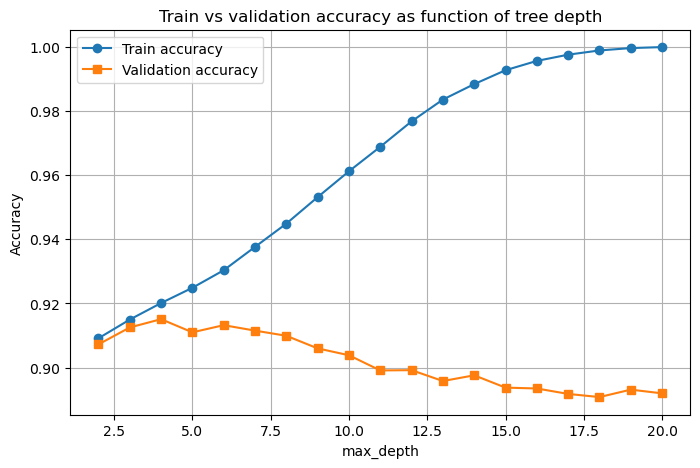

In [9]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Use your existing training set (not the held-out test data)
# X_train, y_train assumed to already exist

nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

depth_values = range(2, 21)  # try depths 2–20

train_acc = np.zeros((nk, len(depth_values)))
val_acc   = np.zeros((nk, len(depth_values)))

for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    for j, d in enumerate(depth_values):
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=1, random_state=0)
        dt.fit(X_t, y_t)

        # accuracy on the fold's train and validation splits
        yhat_train = dt.predict(X_t)
        yhat_val   = dt.predict(X_val)

        train_acc[i, j] = accuracy_score(y_t, yhat_train)
        val_acc[i, j]   = accuracy_score(y_val, yhat_val)

# mean accuracy over folds
mean_train_acc = train_acc.mean(axis=0)
mean_val_acc   = val_acc.mean(axis=0)

print("Depths:", list(depth_values))
print("Mean train accuracy:", mean_train_acc)
print("Mean val accuracy:", mean_val_acc)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depth_values, mean_train_acc, label="Train accuracy", linestyle="-", marker="o")
plt.plot(depth_values, mean_val_acc,   label="Validation accuracy", linestyle="-", marker="s")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs validation accuracy as function of tree depth")
plt.legend()
plt.grid(True)
plt.show()






In [10]:
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.metrics import f1_score

depth_values = [2, 4, 6, 8, 10, 12]
leaf_values  = [1, 5, 10, 20, 50]

nk = 5
kf = KFold(n_splits=nk, random_state=0, shuffle=True)

acc_grid = np.zeros((len(depth_values), len(leaf_values)))
f1_grid  = np.zeros((len(depth_values), len(leaf_values)))

for di, d in enumerate(depth_values):
    for li, leaf in enumerate(leaf_values):

        fold_acc = []
        fold_f1  = []

        for train_index, val_index in kf.split(X_train):
            X_t, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
            y_t, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

            dt = DecisionTreeClassifier(max_depth=d,
                                        min_samples_leaf=leaf,
                                        random_state=0)
            dt.fit(X_t, y_t)
            yhat_val = dt.predict(X_val)

            fold_acc.append(accuracy_score(y_val, yhat_val))
            fold_f1.append(f1_score(y_val, yhat_val))

        acc_grid[di, li] = np.mean(fold_acc)
        f1_grid[di, li]  = np.mean(fold_f1)

print("Validation accuracy grid:\n", acc_grid)
print("Validation F1 grid:\n", f1_grid)

Validation accuracy grid:
 [[0.90723214 0.90723214 0.90723214 0.90723214 0.90723214]
 [0.91508929 0.91508929 0.91526786 0.91535714 0.915625  ]
 [0.91321429 0.91339286 0.91241071 0.91482143 0.91392857]
 [0.90991071 0.90955357 0.90928571 0.91348214 0.91410714]
 [0.90383929 0.90642857 0.90758929 0.91330357 0.91410714]
 [0.89919643 0.90258929 0.90767857 0.91339286 0.91410714]]
Validation F1 grid:
 [[0.47713606 0.47713606 0.47713606 0.47713606 0.47713606]
 [0.55272732 0.55272732 0.55379412 0.55406367 0.54987262]
 [0.56116572 0.55182431 0.55501099 0.55786461 0.53408275]
 [0.55263425 0.53934281 0.53347993 0.53783053 0.53654649]
 [0.52538101 0.53086012 0.51655122 0.53101043 0.53654649]
 [0.49839012 0.50488404 0.50986405 0.52871001 0.53654649]]


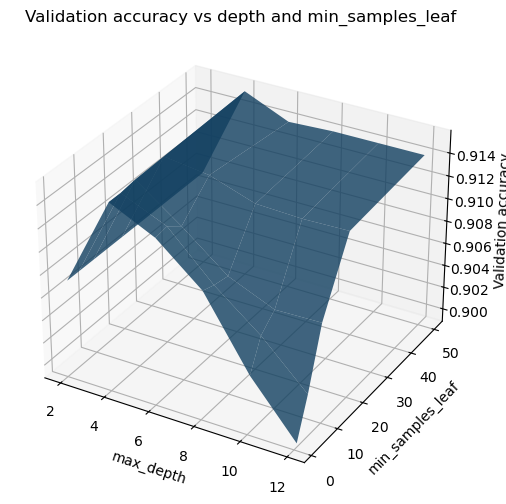

In [11]:
D, L = np.meshgrid(depth_values, leaf_values, indexing="ij")  # same shape as acc_grid

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(D, L, acc_grid, alpha=0.8)
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_zlabel("Validation accuracy")
ax.set_title("Validation accuracy vs depth and min_samples_leaf")
plt.show()

In [12]:
best_index = np.unravel_index(np.argmax(f1_grid), f1_grid.shape)
best_depth = depth_values[best_index[0]]
best_leaf  = leaf_values[best_index[1]]
best_f1_cv = f1_grid[best_index]

print("Best hyperparameters by F1:")
print("  max_depth =", best_depth)
print("  min_samples_leaf =", best_leaf)
print("  mean cross-validated F1 =", best_f1_cv)

Best hyperparameters by F1:
  max_depth = 6
  min_samples_leaf = 1
  mean cross-validated F1 = 0.5611657247690214


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Train final model with best hyperparameters on all training data
final_dt = DecisionTreeClassifier(max_depth=best_depth,
                                  min_samples_leaf=best_leaf,
                                  random_state=0)
final_dt.fit(X_train, y_train)

# Evaluate on held-out test set
y_test_pred = final_dt.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Held-out test performance:")
print("  Accuracy :", test_acc)
print("  Precision:", test_prec)
print("  Recall   :", test_rec)
print("  F1-score :", test_f1)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

Held-out test performance:
  Accuracy : 0.9096428571428572
  Precision: 0.5889830508474576
  Recall   : 0.4711864406779661
  F1-score : 0.5235404896421846

Confusion matrix:
[[2408   97]
 [ 156  139]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2505
           1       0.59      0.47      0.52       295

    accuracy                           0.91      2800
   macro avg       0.76      0.72      0.74      2800
weighted avg       0.90      0.91      0.91      2800



## Task 3. Random Forest
### - Outlier Detection as a Supervised Classification

Now use a [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) to predict the labels for the data set. 

i) use the default values for the parameters to get a RF model running. 

ii) use 5-fold cross-validation to determine a possibly better choice for the parameter *n_estimators* and *max_features*
    
iii) select the best-performing decision tree (i.e., the one that achieved the highest cross-validated performance) and report the performance of the fitted model on the held-out test data ?

In the report, reflect on how does the test performance of RF compare to the decision tree performance? 
 



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Generate the dataset
X, y = make_classification(
    n_samples=1000, n_features=4,
    n_informative=2, n_redundant=0,
    random_state=0, shuffle=False
)

# Split into training and held-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# i) Train a Random Forest using default parameters
rf_default = RandomForestClassifier() 
rf_default.fit(X_train, y_train)
default_test_acc = accuracy_score(y_test, rf_default.predict(X_test))

print("Default RF test accuracy:", default_test_acc)

# ii) 5-fold cross-validation for n_estimators + max_features
param_grid = {
    "n_estimators": [50, 100, 200, 500],
    "max_features": ["sqrt", "log2", None]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# iii) Evaluate the best-performing model on the test set
best_rf = grid.best_estimator_
best_test_acc = accuracy_score(y_test, best_rf.predict(X_test))

print("Best RF test accuracy:", best_test_acc)


Default RF test accuracy: 0.94
Best parameters: {'max_features': 'sqrt', 'n_estimators': 100}
Best CV score: 0.96
Best RF test accuracy: 0.935


## Task 4. Isolation Forest

### 4.1 Apply Isolation Forest
### - Outlier Detection as an Unsupervised Classification

Use the [Isolation Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) to detect potential outliers in the data set. 

Select two parameters that you would like to investigate (for example, contamination, max_depth, n_estimators, max_samples). For each configuration: 

i) Apply Isolation Forest on the full data set (without using the labels Y)


ii) Use the labels to compute the accuracy, recall, precision, and F1-score on the full data set (using the labels). 


Compare the performance of Isolation Forest of different configurations. 


#### Tips:

- Note that the fit(X) function of the Isolation Forest does not use the labels. 


- **Look carefully at the values that an Isolation Forest classifier returns. Which value represents the outlier class? Be aware that you need to implement a mapping function f(x) that remaps -1 to 1 and 1 to 0, in order to transform the predictions such that the semantics are consistant with the previous classification algorithms.**


- Create 2D (or 3D) plots to visualize your results



Config: {'contamination': 0.05, 'n_estimators': 100}

Accuracy:  0.8885
Precision: 0.4149
Recall:    0.2014
F1-score:  0.2712


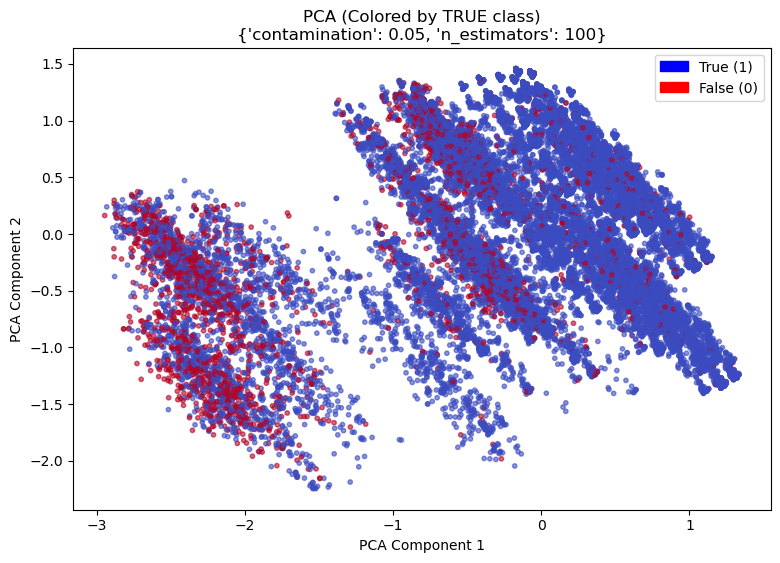

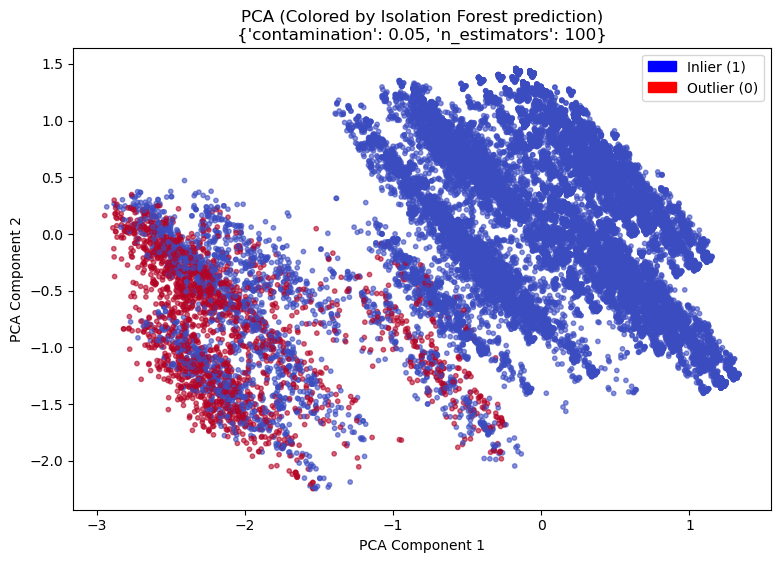

Config: {'contamination': 0.1, 'n_estimators': 200}

Accuracy:  0.8639
Precision: 0.3344
Recall:    0.3246
F1-score:  0.3295


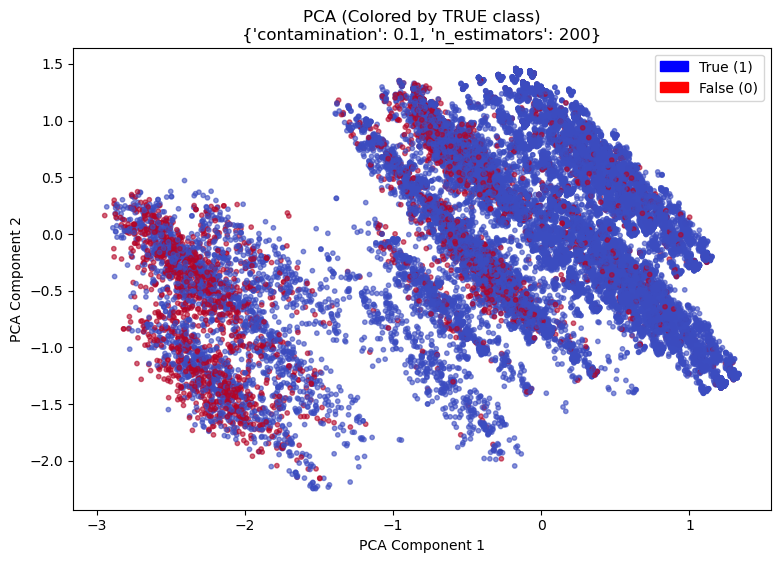

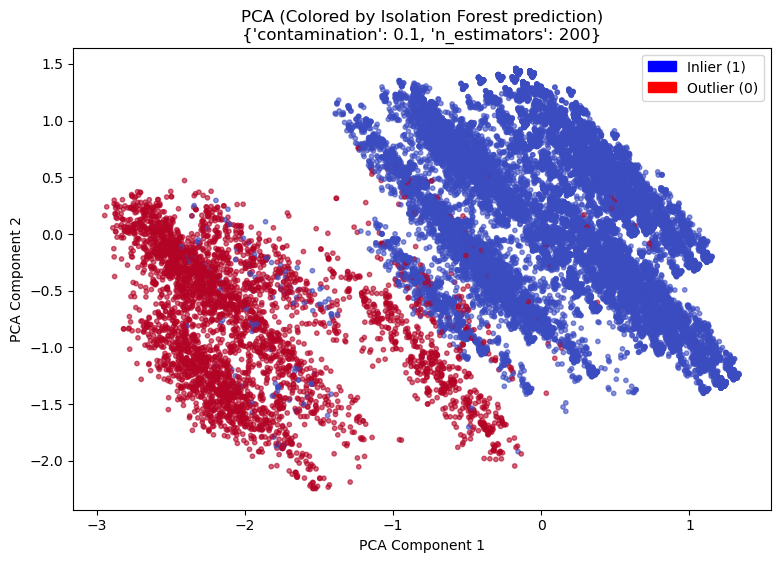

Config: {'contamination': 0.05, 'n_estimators': 200}

Accuracy:  0.8860
Precision: 0.3905
Recall:    0.1896
F1-score:  0.2553


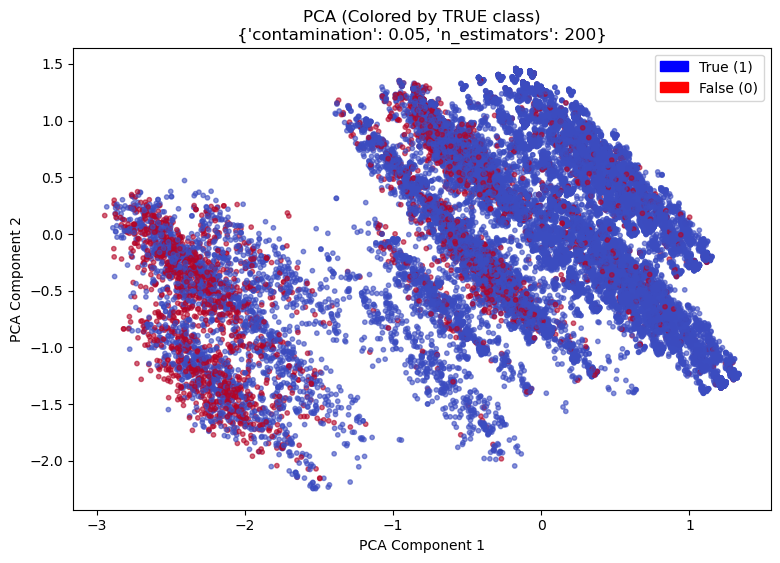

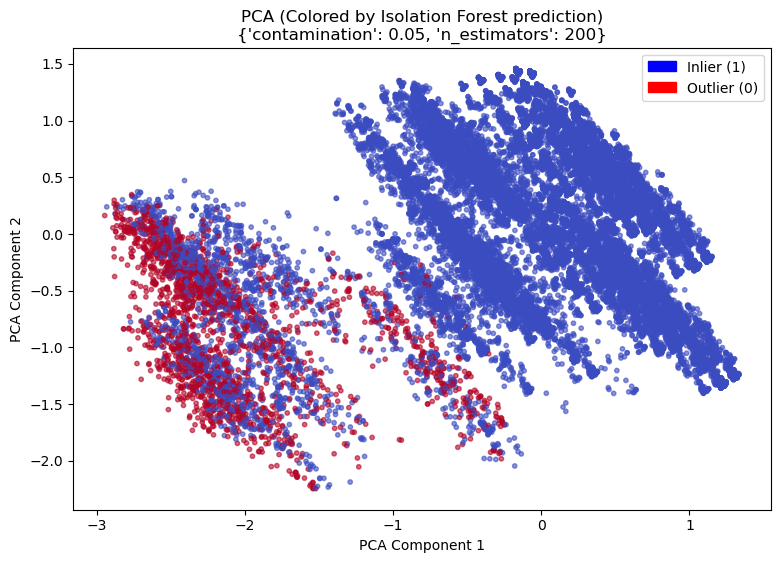

Config: {'contamination': 0.1, 'n_estimators': 100}

Accuracy:  0.8644
Precision: 0.3369
Recall:    0.3271
F1-score:  0.3319


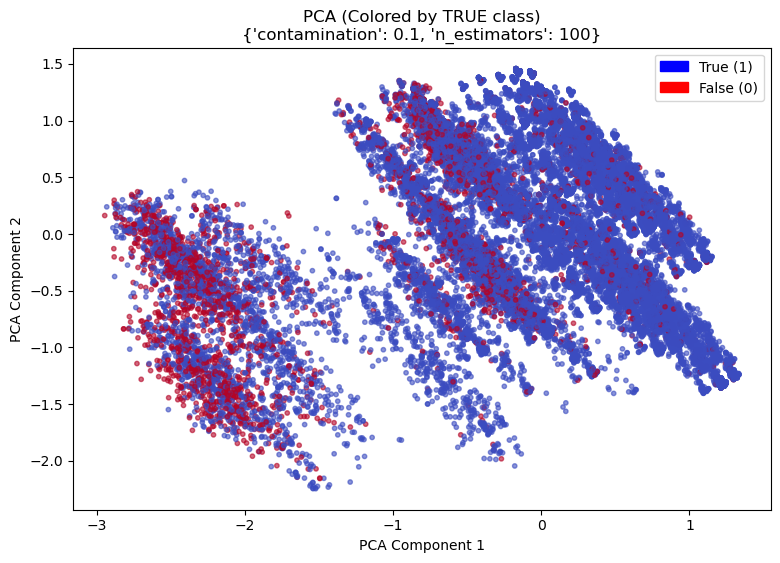

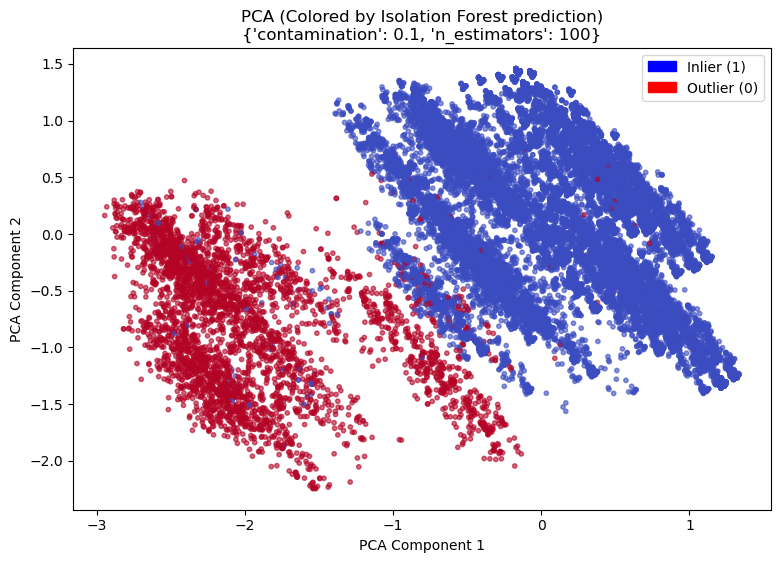

In [34]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

X = data.drop(columns=['class'])
y_true = data['class']   # 0 = negative, 1 = positive


def map_iforest_pred(pred):
    # -1 → outlier (1), 1 → inlier (0)
    return (pred == -1).astype(int)

configs = [
    {"contamination": 0.05, "n_estimators": 100},
    {"contamination": 0.10, "n_estimators": 200},
    {"contamination": 0.05, "n_estimators": 200},
    {"contamination": 0.10, "n_estimators": 100},
]


results = []

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

for cfg in configs:
    print(f"Config: {cfg}\n")

    model = IsolationForest(
        contamination=cfg["contamination"],
        n_estimators=cfg["n_estimators"],
        random_state=42
    )
    model.fit(X)

    preds_raw = model.predict(X)
    preds = map_iforest_pred(preds_raw)  # mapped to 0/1

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_true,
        cmap="coolwarm",
        alpha=0.6,
        s=10
    )
    plt.title(f"PCA (Colored by TRUE class)\n{cfg}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    inlier_patch = mpatches.Patch(color="blue", label="True (1)")
    outlier_patch = mpatches.Patch(color="red", label="False (0)")
    plt.legend(handles=[inlier_patch, outlier_patch])
    plt.show()

    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=preds,
        cmap="coolwarm",
        alpha=0.6,
        s=10
    )
    plt.title(f"PCA (Colored by Isolation Forest prediction)\n{cfg}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    inlier_patch = mpatches.Patch(color="blue", label="Inlier (1)")
    outlier_patch = mpatches.Patch(color="red", label="Outlier (0)")
    plt.legend(handles=[inlier_patch, outlier_patch])
    plt.show()

    results.append({
        "config": cfg,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "model": model    # <-- IMPORTANT: add model here!
    })



### 4.2 Outlier Detection - Analyze Outliers

Taking the best performing Isolation Forest model from Task 4.1, enrich the data set with the predicted labels (or scores) by the model. 

Perform one or two analyses to show the characteristics of the outliers. 

In [ ]:
best_result = max(results, key=lambda r: r["f1"])
best_config = best_result["config"]

print("Best Isolation Forest Model:\n")
print(best_config)
print("\nF1-score:", best_result["f1"])

best_model = IsolationForest(
    contamination=best_config["contamination"],
    n_estimators=best_config.get("n_estimators", 100),
    random_state=42
)
best_model.fit(X)

df["IF_pred_raw"] = best_model.predict(X)
df["IF_pred"] = (df["IF_pred_raw"] == -1).astype(int)
df["IF_score"] = best_model.decision_function(X)

job_cols = [c for c in df.columns if c.startswith("job=")]
if job_cols:
    df["job"] = df[job_cols].idxmax(axis=1).str.replace("job=", "", regex=False)
else:
    df["job"] = np.nan

education_cols = [c for c in df.columns if c.startswith("education=")]
if education_cols:
    df["education"] = df[education_cols].idxmax(axis=1).str.replace("education=", "", regex=False)
else:
    df["education"] = np.nan

print("\nSummary statistics for OUTLIERS vs INLIERS")

outliers = df[df["IF_pred"] == 1]
inliers = df[df["IF_pred"] == 0]

print("Counts:")
print(df["IF_pred"].value_counts())
print("\nSummary (Outliers):")
print(outliers.describe().T)
print("\nSummary (Inliers):")
print(inliers.describe().T)

print("Inlier distribution - Job:")
print(inliers["job"].value_counts(normalize=True))

print("\nOutlier distribution - Job:")
print(outliers["job"].value_counts(normalize=True))

print("Inlier distribution - Education:")
print(inliers["education"].value_counts(normalize=True))

print("\nOutlier distribution - Education:")
print(outliers["education"].value_counts(normalize=True))

Best Isolation Forest Model:

{'contamination': 0.1, 'n_estimators': 100}

F1-score: 0.33190341953670793

Summary statistics for OUTLIERS vs INLIERS
Counts:
IF_pred
0    36169
1     4019
Name: count, dtype: int64

Summary (Outliers):
                  count      mean       std       min       25%       50%  \
age              4019.0  0.324050  0.188758  0.000000  0.172840  0.283951   
job=housemaid    4019.0  0.041801  0.200160  0.000000  0.000000  0.000000   
job=services     4019.0  0.082110  0.274566  0.000000  0.000000  0.000000   
job=admin.       4019.0  0.194078  0.395539  0.000000  0.000000  0.000000   
job=blue-collar  4019.0  0.121174  0.326370  0.000000  0.000000  0.000000   
...                 ...       ...       ...       ...       ...       ...   
nr.employed      4019.0  0.413262  0.313805  0.000000  0.170510  0.425709   
class            4019.0  0.336900  0.472709  0.000000  0.000000  0.000000   
IF_pred_raw      4019.0 -1.000000  0.000000 -1.000000 -1.000000 -1.000000

## Task 5. Report your results and discuss your findings

### 5.1 Compare the performances 

By now, you have applied three algorithms with different parameters on the data set. For each algorithm, you have create tables or figures which you can add to your report. Discuss the results and their optimal performance. 

Create an overview table or figure that show the optimal performance of each algorithm on the data set, for example see the table here below. 

Discuss your findings in the report and reflect on the following questions:
- According to the performance results, which one is the optimal model? 
- How large is the difference between the accuracy score and the F1 score for each model? What caused the difference?
- Which of performance measures (the accuracy score, recall, precision, or F1-score) would you use for comparing the model performance? Why?
- You are comparing the performance of supervised algorithms (DT and RF) with an unsupervised algorithm (Isolation Forest). Is this a fair comparison? Motivate your answer. 



| Model | Validation Accuracy  | Test Accuracy |  Validation Recall  |  Test Recall  | Validation F1 | Test F1 |... |
|------|------|------|------|------|------|------|-----|
|   Decision Tree        |  |  | | | | |
|   Random Forest  |  |  | || | |
|   Isolation Forest        |  |  | || | |



### 5.2 Analyze and discuss the results

For each optimal model, enrich your test set by adding the predicted labels by this model to the test set. Can you think of an analysis that gives insights into when the model performs poorly?

Discuss the analysis and insights in the report

## Bonus Tasks 

We would like to challenge you with the following bonus tasks. For each task that is successfully completed, you may obtain max. 0.5 extra point. 

### Bonus Task 1

Implement another outlier detection algorithm (for example, LOF, OC-SVM, Autoencoder) or design your own outlier detection algorithm that achieves a better F1 score. 




### Bonus Task 2 

Implement techniques (e.g., preprocessing, feature engineering, sampling) that help improve the F1 scores of existing models


### Prediction Challenge 

- Import the independent test set without labels, apply your best performing model on this test set. 

- Enrich the test set with the predicted labels (**name this column 'predictedClass'**) 

- Export both the model as pkl file and the enriched test data set as a csv file. 

- The top three teams that have achieved the best accuracy score wins max. 0.3 bonus points.




In [ ]:
import pickle

# import data
data_challenge = pd.read_csv('./dataBank-new_test_nolabel.csv', sep=',')
X_new = data_challenge[features]
print(X_new.describe())

# TODO: assign optimal model 
optimal_model = ...

yhat = optimal_model.predict(X_new)

# TODO: enrich the data with the predicted labels by adding the column 'predictedClass'


# TODO: export the enriched data to disk





FileNotFoundError: [Errno 2] No such file or directory: './dataBank-new_test_nolabel.csv'

In [ ]:
import sklearn
print(sklearn.__version__)
